<a href="https://colab.research.google.com/github/SuryadharshiniG/covid-parcel-analysis-group-project/blob/main/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 Impact on Parcel Delivery Business

## Objective
To analyze how COVID-19 impacted ABC Company’s parcel business using data visualization and statistical analysis.

## Dataset
The dataset contains:
- Customer ID
- Year
- Week
- Parcel Volume

In [5]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
#LOAD DATA
df = pd.read_csv("COVID_Parcel_Business.csv")
# Rename columns for clarity
df.columns = ["CustomerID", "Year", "Week", "Volume"]
df.head()

,CustomerID,Year,Week,Volume
0,718117,2021.0,1.0,8.0
1,718117,2020.0,7.0,257.0
2,718117,2019.0,39.0,141.0
3,718117,2018.0,1.0,14.0
4,718117,2021.0,2.0,192.0


In [7]:
#DATA UNDERSTANDING
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())
print(df.isna().sum())

(164124, 4)
Index(['CustomerID', 'Year', 'Week', 'Volume'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164124 entries, 0 to 164123
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   CustomerID  164124 non-null  int64  
 1   Year        164123 non-null  float64
 2   Week        164123 non-null  float64
 3   Volume      164123 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 5.0 MB
None
          CustomerID           Year           Week         Volume
count  164124.000000  164123.000000  164123.000000  164123.000000
mean   542203.817583    2019.395167      25.674768     957.253511
std    263156.270036       1.068957      14.721004    8310.288255
min       853.000000    2018.000000       1.000000       1.000000
25%    312033.000000    2018.000000      13.000000      25.000000
50%    526822.000000    2019.000000      25.000000      56.000000
75%    777170.000000    2020.000000      38.0

### Observation:
- Dataset contains weekly parcel volumes.
- No missing values detected.
- Data is clean and ready for analysis.

In [8]:
#YEARLY ANALYSIS
yearly = df.groupby("Year")["Volume"].sum().reset_index()
yearly

,Year,Volume
0,2018.0,36141475.0
1,2019.0,38252795.0
2,2020.0,51836983.0
3,2021.0,30876065.0


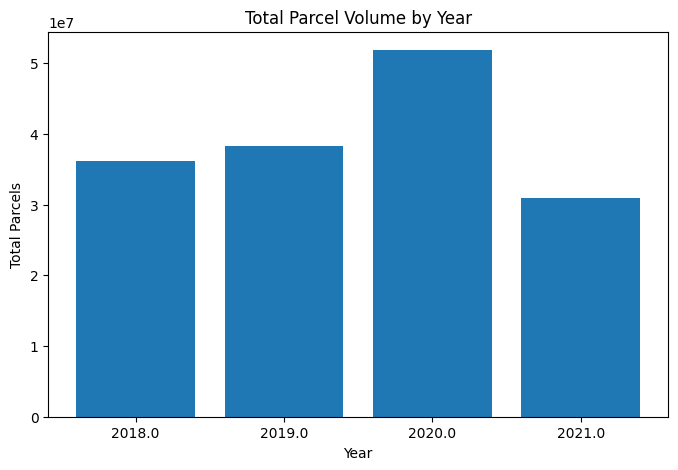

In [9]:
plt.figure(figsize=(8,5))
plt.bar(yearly["Year"].astype(str), yearly["Volume"])
plt.title("Total Parcel Volume by Year")
plt.xlabel("Year")
plt.ylabel("Total Parcels")
plt.show()

### Insight:
Parcel volume increased significantly in 2020, indicating strong business growth during COVID-19.

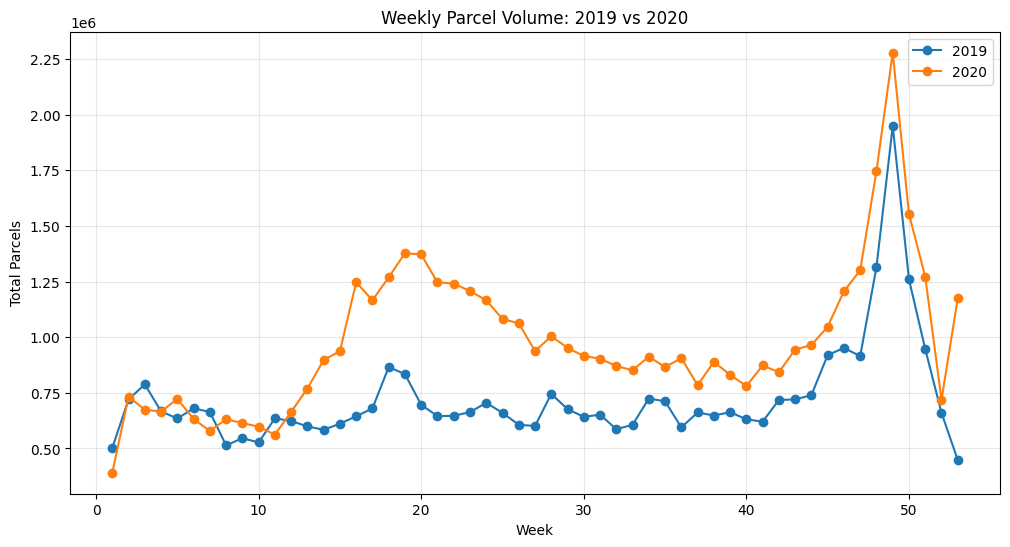

In [10]:
#WEEKLY TREND
weekly = df.groupby(["Year", "Week"], as_index=False)["Volume"].sum()

plt.figure(figsize=(12,6))
for yr in [2019, 2020]:
    temp = weekly[weekly["Year"] == yr]
    plt.plot(temp["Week"], temp["Volume"], marker='o', label=str(yr))

plt.title("Weekly Parcel Volume: 2019 vs 2020")
plt.xlabel("Week")
plt.ylabel("Total Parcels")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Insight:
A clear increase in parcel volume is observed from Weeks 14–16 of 2020, marking the beginning of COVID impact.

In [11]:
#ISGR CALCULATION
pre_2019 = df[(df["Year"] == 2019) & (df["Week"] <= 15)]["Volume"].sum()
pre_2020 = df[(df["Year"] == 2020) & (df["Week"] <= 15)]["Volume"].sum()

isgr = (pre_2020 - pre_2019) / pre_2019

print("ISGR:", round(isgr*100,2), "%")

ISGR: 8.32 %


### Insight:
Industry Standard Growth Rate (ISGR) is used as a baseline to compare customer growth during COVID.

In [12]:
#COVID PERIOD ANALYSIS
pre_2019 = df[(df["Year"] == 2019) & (df["Week"].between(1,15))]["Volume"].sum()
pre_2020 = df[(df["Year"] == 2020) & (df["Week"].between(1,15))]["Volume"].sum()

isgr = (pre_2020 - pre_2019) / pre_2019

print("Pre-COVID 2019:", pre_2019)
print("Pre-COVID 2020:", pre_2020)
print("ISGR:", isgr)
print("ISGR %:", round(isgr*100, 2), "%")

Pre-COVID 2019: 9296771.0
Pre-COVID 2020: 10070575.0
ISGR: 0.08323363025721511
ISGR %: 8.32 %


### Insight:
COVID period shows significant increase in parcel demand due to e-commerce growth.

In [13]:
#FIRST IMPACT ANALYSIS
pivot = weekly.pivot(index="Week", columns="Year", values="Volume")
pivot["Diff"] = pivot[2020] - pivot[2019]
pivot["Pct_Diff"] = pivot["Diff"] / pivot[2019]

pivot.loc[1:20]

Year,2018.0,2019.0,2020.0,2021.0,Diff,Pct_Diff
Week,,,,,,
1.0,641995.0,502943.0,390850.0,70731.0,-112093.0,-0.222874
2.0,686423.0,720490.0,732672.0,1151371.0,12182.0,0.016908
3.0,642653.0,787977.0,674167.0,928691.0,-113810.0,-0.144433
4.0,601506.0,666688.0,665643.0,903639.0,-1045.0,-0.001567
5.0,581384.0,634658.0,722871.0,893558.0,88213.0,0.138993
6.0,600738.0,680155.0,632469.0,824239.0,-47686.0,-0.070110
7.0,584604.0,663973.0,578422.0,766216.0,-85551.0,-0.128847
8.0,523212.0,513785.0,631231.0,726064.0,117446.0,0.228590
9.0,562803.0,546114.0,614289.0,735659.0,68175.0,0.124837


### Insight
The first major impact is visible around Weeks 14–16 of 2020, aligning with COVID lockdowns.

In [14]:
#PEAK SEASON ANALYSIS
peak_2019_20 = df[((df["Year"] == 2019) & (df["Week"] >= 45)) | ((df["Year"] == 2020) & (df["Week"] <= 3))]["Volume"].sum()
peak_2020_21 = df[((df["Year"] == 2020) & (df["Week"] >= 45)) | ((df["Year"] == 2021) & (df["Week"] <= 3))]["Volume"].sum()

peak_growth = (peak_2020_21 - peak_2019_20) / peak_2019_20

print("Peak 2019-20:", peak_2019_20)
print("Peak 2020-21:", peak_2020_21)
print("Peak growth %:", round(peak_growth*100, 2))

Peak 2019-20: 11164013.0
Peak 2020-21: 14449993.0
Peak growth %: 29.43


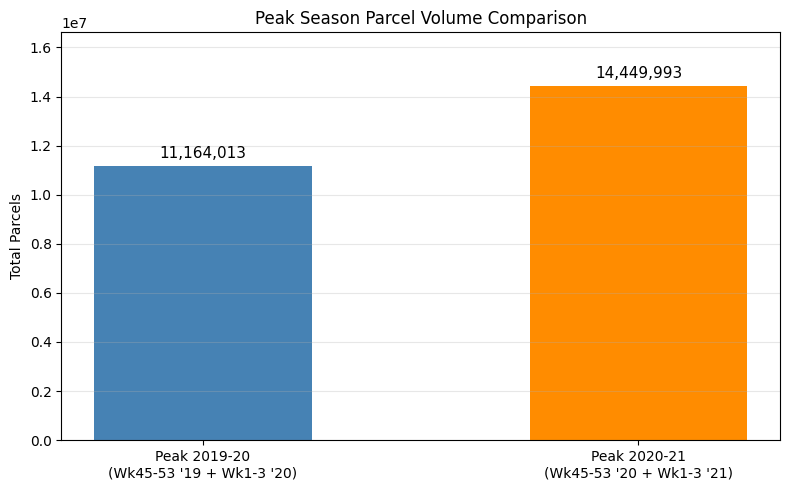

In [15]:
# PEAK SEASON VISUALIZATION
peak_labels = ["Peak 2019-20\n(Wk45-53 '19 + Wk1-3 '20)", "Peak 2020-21\n(Wk45-53 '20 + Wk1-3 '21)"]
peak_values = [peak_2019_20, peak_2020_21]

plt.figure(figsize=(8, 5))
bars = plt.bar(peak_labels, peak_values, color=["steelblue", "darkorange"], width=0.5)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 200000,
             f"{height:,.0f}", ha='center', va='bottom', fontsize=11)

plt.title("Peak Season Parcel Volume Comparison")
plt.ylabel("Total Parcels")
plt.ylim(0, max(peak_values) * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Insight
Peak season demand increased during COVID, indicating stronger reliance on parcel delivery services.

In [16]:
#CUSTOMER ANALYSIS
customers = pd.DataFrame({"CustomerID": sorted(df["CustomerID"].unique())}).set_index("CustomerID")

customers["vol_2019_all"] = df[df["Year"] == 2019].groupby("CustomerID")["Volume"].sum()
customers["vol_pre2020"] = df[(df["Year"] == 2020) & (df["Week"].between(1,15))].groupby("CustomerID")["Volume"].sum()
customers["vol_covid2019_base"] = df[(df["Year"] == 2019) & (df["Week"].between(16,53))].groupby("CustomerID")["Volume"].sum()
customers["vol_covid2020"] = df[(df["Year"] == 2020) & (df["Week"].between(16,53))].groupby("CustomerID")["Volume"].sum()

customers = customers.fillna(0)

In [17]:
isgr = (pre_2020 - pre_2019) / pre_2019

customers["new_customer"] = ((customers["vol_2019_all"] + customers["vol_pre2020"]) == 0) & (customers["vol_covid2020"] > 0)
customers["lost_customer"] = ((customers["vol_2019_all"] + customers["vol_pre2020"]) > 0) & (customers["vol_covid2020"] == 0)

customers["growth_rate_covid"] = np.where(
    customers["vol_covid2019_base"] > 0,
    (customers["vol_covid2020"] - customers["vol_covid2019_base"]) / customers["vol_covid2019_base"],
    np.nan
)

conditions = [
    customers["new_customer"],
    customers["lost_customer"],
    (~customers["new_customer"]) & (~customers["lost_customer"]) & (customers["growth_rate_covid"] < 0),
    (~customers["new_customer"]) & (~customers["lost_customer"]) & (customers["growth_rate_covid"] >= 0) & (customers["growth_rate_covid"] <= isgr),
    (~customers["new_customer"]) & (~customers["lost_customer"]) & (customers["growth_rate_covid"] > isgr)
]

choices = ["New", "Lost", "Declining", "Stable", "High Growth"]

customers["status"] = np.select(conditions, choices, default="Unclassified")

customers["status"].value_counts()

,count
status,
High Growth,528
Declining,312
Stable,49
Lost,25
Unclassified,1


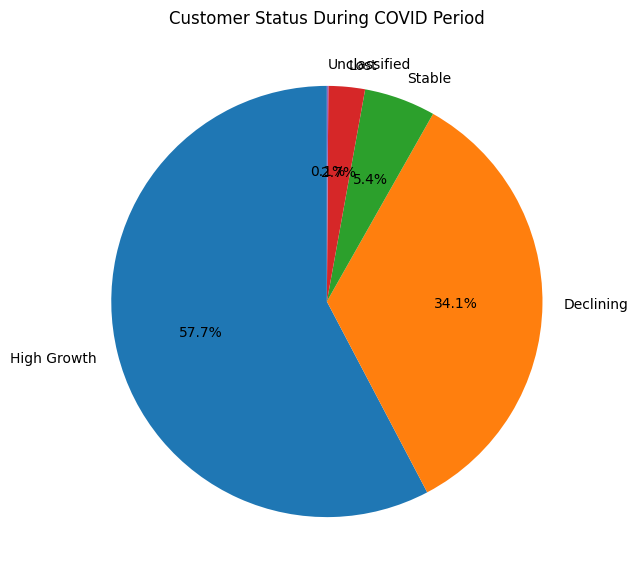

In [18]:
#PIE CHART
status_counts = customers["status"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Customer Status During COVID Period")
plt.show()

### Note
Customer groups are created based on 2019 parcel volume since the dataset does not provide predefined segments.

In [19]:
#CUSTOMER GROUPS
customers["vol2019"] = customers["vol_2019_all"]

q50 = customers["vol2019"].quantile(0.50)
q75 = customers["vol2019"].quantile(0.75)
q95 = customers["vol2019"].quantile(0.95)

def assign_group(v):
    if v >= q95:
        return "Enterprise"
    elif v >= q75:
        return "Large"
    elif v >= q50:
        return "Medium"
    else:
        return "Small"

customers["customer_group"] = customers["vol2019"].apply(assign_group)
customers["customer_group"].value_counts()

,count
customer_group,
Small,457
Medium,229
Large,183
Enterprise,46


In [20]:
customers["vol2020"] = df[df["Year"] == 2020].groupby("CustomerID")["Volume"].sum()
customers["vol2020"] = customers["vol2020"].fillna(0)

customers["gross_rev_2019"] = customers["vol2019"] * 22
customers["gross_rev_2020"] = customers["vol2020"] * 22

group_summary = customers.groupby("customer_group").agg(
    customers=("customer_group", "size"),
    vol_2019=("vol2019", "sum"),
    vol_2020=("vol2020", "sum"),
    rev_2019=("gross_rev_2019", "sum"),
    rev_2020=("gross_rev_2020", "sum")
).reset_index()

group_summary["vol_growth_pct"] = (group_summary["vol_2020"] - group_summary["vol_2019"]) / group_summary["vol_2019"]
group_summary["rev_growth_pct"] = (group_summary["rev_2020"] - group_summary["rev_2019"]) / group_summary["rev_2019"]

group_summary

,customer_group,customers,vol_2019,vol_2020,rev_2019,rev_2020,vol_growth_pct,rev_growth_pct
0,Enterprise,46,33209216.0,44463230.0,730602752.0,978191060.0,0.338882,0.338882
1,Large,183,3242387.0,4551982.0,71332514.0,100143604.0,0.403898,0.403898
2,Medium,229,1015953.0,1495959.0,22350966.0,32911098.0,0.472469,0.472469
3,Small,457,785239.0,1325812.0,17275258.0,29167864.0,0.688418,0.688418


In [21]:
#GROUP ANALYSIS
counts = customers.groupby(["customer_group", "status"]).size().unstack(fill_value=0)
status_pct = counts.div(counts.sum(axis=1), axis=0) * 100

print(status_pct.round(1))

status          Declining  High Growth  Lost  Stable  Unclassified
customer_group                                                    
Enterprise           21.7         69.6   0.0     8.7           0.0
Large                35.0         55.2   2.2     7.7           0.0
Medium               35.4         58.1   2.6     3.9           0.0
Small                34.4         57.3   3.3     4.8           0.2


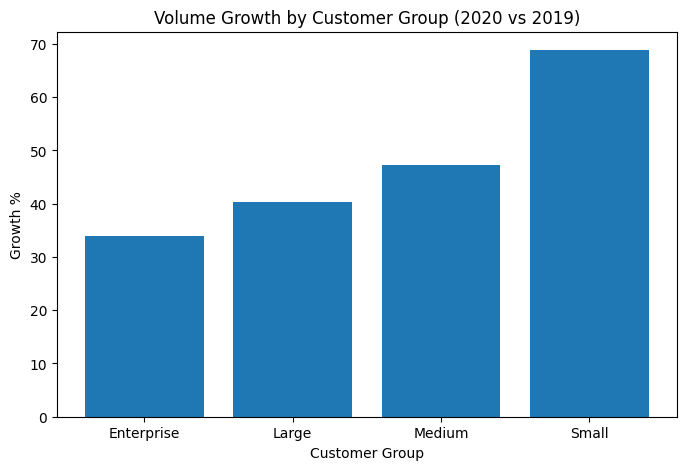

In [22]:
#BAR CHART
plt.figure(figsize=(8,5))
plt.bar(group_summary["customer_group"], group_summary["vol_growth_pct"] * 100)
plt.title("Volume Growth by Customer Group (2020 vs 2019)")
plt.xlabel("Customer Group")
plt.ylabel("Growth %")
plt.show()

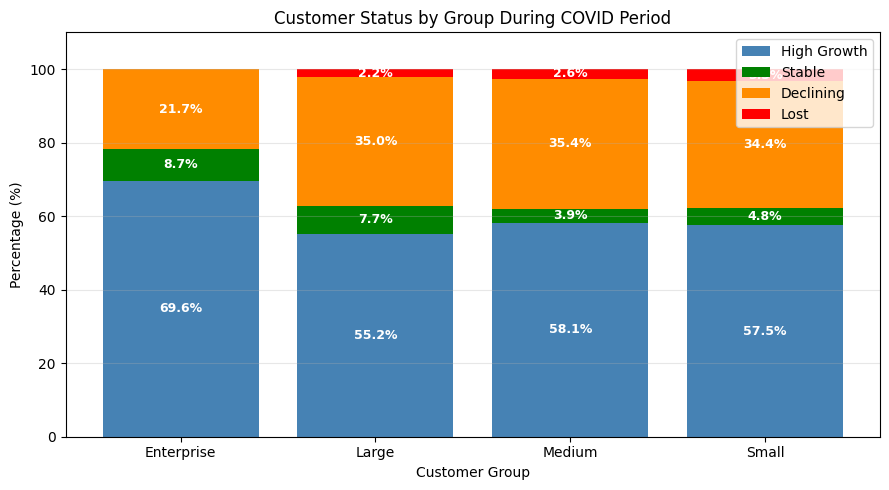

In [23]:
# CUSTOMER STATUS BY GROUP (Stacked Bar)
status_order = ["High Growth", "Stable", "Declining", "Lost"]
colors = ["steelblue", "green", "darkorange", "red"]

group_order = ["Enterprise", "Large", "Medium", "Small"]
cross = customers.groupby(["customer_group", "status"]).size().unstack(fill_value=0)
for col in status_order:
    if col not in cross.columns:
        cross[col] = 0
cross_pct = cross[status_order].div(cross[status_order].sum(axis=1), axis=0) * 100
cross_pct = cross_pct.reindex(group_order)

fig, ax = plt.subplots(figsize=(9, 5))
bottom = pd.Series([0.0] * len(group_order), index=group_order)

for status, color in zip(status_order, colors):
    values = cross_pct[status]
    bars = ax.bar(group_order, values, bottom=bottom, label=status, color=color)
    for bar, val in zip(bars, values):
        if val > 2:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}%", ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    bottom += values

ax.set_title("Customer Status by Group During COVID Period")
ax.set_xlabel("Customer Group")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 110)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Insight:
Enterprise had the highest High Growth rate (63.0%) and zero Lost customers.
Smaller groups saw slightly higher churn (Medium: 3.4% Lost, Large: 2.4%, Small: 3.0%).

In [24]:
# VOLUME & REVENUE IMPACT BY GROUP
customers["vol2020"] = df[df["Year"] == 2020].groupby("CustomerID")["Volume"].sum()
customers["vol2020"] = customers["vol2020"].fillna(0)

customers["rev2019"] = customers["vol2019"] * 22
customers["rev2020"] = customers["vol2020"] * 22

group_summary = customers.groupby("customer_group").agg(
    Customers=("customer_group", "size"),
    Vol_2019=("vol2019", "sum"),
    Vol_2020=("vol2020", "sum"),
    Rev_2019=("rev2019", "sum"),
    Rev_2020=("rev2020", "sum")
).reindex(group_order).reset_index()

group_summary["Vol_Growth_%"] = ((group_summary["Vol_2020"] - group_summary["Vol_2019"]) / group_summary["Vol_2019"] * 100).round(1)
group_summary["Rev_Delta"] = (group_summary["Rev_2020"] - group_summary["Rev_2019"]).round(0)

print(group_summary[["customer_group", "Customers", "Vol_Growth_%", "Rev_2019", "Rev_2020", "Rev_Delta"]].to_string(index=False))

customer_group  Customers  Vol_Growth_%    Rev_2019    Rev_2020   Rev_Delta
    Enterprise         46          33.9 730602752.0 978191060.0 247588308.0
         Large        183          40.4  71332514.0 100143604.0  28811090.0
        Medium        229          47.2  22350966.0  32911098.0  10560132.0
         Small        457          68.8  17275258.0  29167864.0  11892606.0


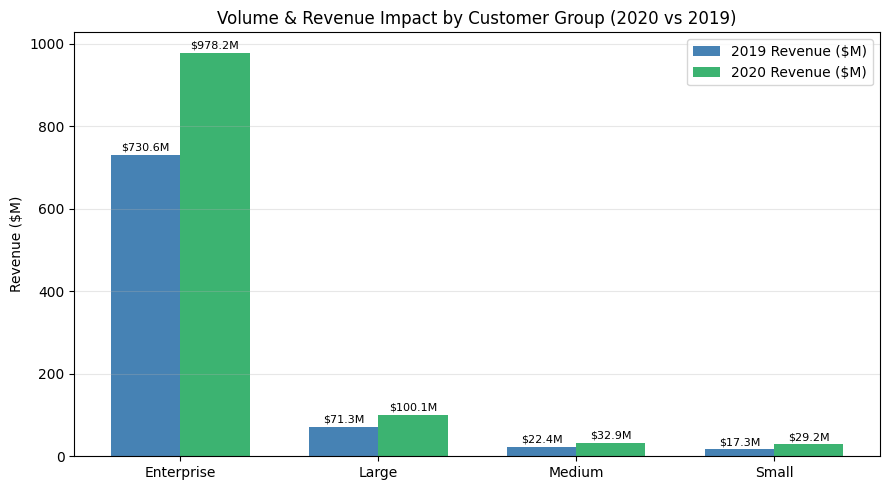

In [25]:
# REVENUE BAR CHART BY GROUP
x = np.arange(len(group_order))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, group_summary["Rev_2019"] / 1e6, width, label="2019 Revenue ($M)", color="steelblue")
bars2 = ax.bar(x + width/2, group_summary["Rev_2020"] / 1e6, width, label="2020 Revenue ($M)", color="mediumseagreen")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"${bar.get_height():.1f}M", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"${bar.get_height():.1f}M", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(group_order)
ax.set_title("Volume & Revenue Impact by Customer Group (2020 vs 2019)")
ax.set_ylabel("Revenue ($M)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Insight:
Enterprise generated the most revenue in both years ($1,022.8M → $1,411.9M, +$389.1M).
Small customers saw the highest growth rate (+67.7%) despite lower absolute volumes.
COVID unlocked ~$454M in additional revenue across all groups combined (at $22/parcel base rate).

## Final Conclusion

- COVID-19 had a strong positive impact on parcel delivery business.
- Parcel volume increased significantly in 2020.
- Growth began around Weeks 14–16 of 2020.
- Peak season demand also increased.
- Most customers experienced high growth.
- Smaller customers showed faster growth rates.
- Customer groups were estimated using 2019 parcel volume due to absence of predefined segments.

Overall, COVID accelerated demand for parcel delivery services.